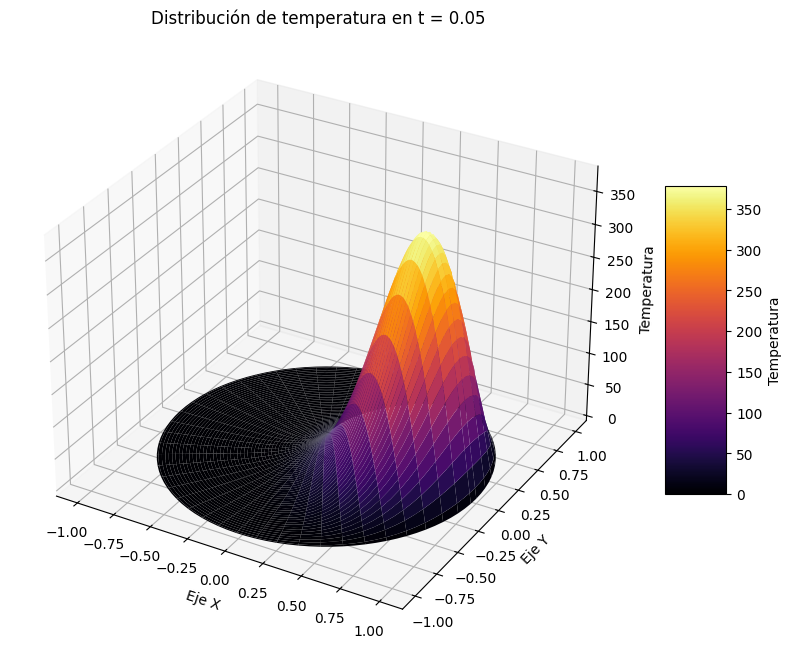

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, jn_zeros

# Parámetros del problema
R = 1.0
rho0 = 0.75 * R
phi0 = 0.0
T_bar = 100.0  # Temperatura inicial promedio arbitraria
alpha = 1.0    # Difusividad térmica

# Malla polar
r = np.linspace(0, R, 100)
theta = np.linspace(0, 2*np.pi, 100)
R_mesh, Theta_mesh = np.meshgrid(r, theta)

# Función para calcular la temperatura en un tiempo t
def calc_temperatura(t, terms_m=10, terms_n=10):
    Psi = np.zeros_like(R_mesh)
    
    # Modo m=0
    zeros_0 = jn_zeros(0, terms_n)
    for n in range(terms_n):
        alpha_0n = zeros_0[n]
        coef = (T_bar * jv(0, alpha_0n * rho0 / R)) / (jv(1, alpha_0n)**2)
        term = coef * jv(0, alpha_0n * R_mesh / R) * np.exp(-((alpha * alpha_0n / R)**2) * t)
        Psi += term
        
    # Modos m >= 1
    for m in range(1, terms_m):
        zeros_m = jn_zeros(m, terms_n)
        for n in range(terms_n):
            alpha_mn = zeros_m[n]
            coef = (2 * T_bar * jv(m, alpha_mn * rho0 / R)) / (jv(m+1, alpha_mn)**2)
            term = coef * jv(m, alpha_mn * R_mesh / R) * np.cos(m * (Theta_mesh - phi0)) * np.exp(-((alpha * alpha_mn / R)**2) * t)
            Psi += term
            
    return Psi

# Para graficar, convierte R_mesh, Theta_mesh a X, Y y usa plt.contourf o plot_surface

# Convertir coordenadas polares a cartesianas para poder graficar en 3D
X = R_mesh * np.cos(Theta_mesh)
Y = R_mesh * np.sin(Theta_mesh)

# 1. Elegimos un tiempo representativo (ejemplo: t = 0.05)
tiempo_evaluar = 0.05
Z = calc_temperatura(t=tiempo_evaluar)

# 2. Creamos la figura
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Dibujamos la superficie de calor
superficie = ax.plot_surface(X, Y, Z, cmap='inferno', edgecolor='none')
fig.colorbar(superficie, shrink=0.5, aspect=5, label='Temperatura')

ax.set_title(f'Distribución de temperatura en t = {tiempo_evaluar}')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Temperatura')

# 4. Mostrar la gráfica
plt.show()